### Auto-Reload & Imports

In [1]:
# Automatically reload external Python modules when modified
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

# Import custom OOP modules
from modules.preprocessor import DataPreprocessor
from modules.feature_builder import FeatureBuilder
from modules.models import ModelSuite
from modules.optimizer import OptimusEnsemble


### Data Loading

In [3]:
import pandas as pd 
data = "/Users/aryanmishra/Documents/tp-forecasting/Call Center Data.csv"
df = pd.read_csv(data)
df.head(5)

,Index,Incoming Calls,Answered Calls,Answer Rate,Abandoned Calls,Answer Speed (AVG),Talk Duration (AVG),Waiting Time (AVG),Service Level (20 Seconds)
0,1,217,204,94.01%,13,0:00:17,0:02:14,0:02:45,76.28%
1,2,200,182,91.00%,18,0:00:20,0:02:22,0:06:55,72.73%
2,3,216,198,91.67%,18,0:00:18,0:02:38,0:03:50,74.30%
3,4,155,145,93.55%,10,0:00:15,0:02:29,0:03:12,79.61%
4,5,37,37,100.00%,0,0:00:03,0:02:06,0:00:35,97.30%


### Data Ingestion & Model Pipeline

In [4]:
# 1. Preprocess Data
preprocessor = DataPreprocessor(target_col='Incoming Calls')
df_clean = preprocessor.fit_transform(df)

# 2. Build Features
feature_builder = FeatureBuilder(target_col='Incoming Calls')
X, y = feature_builder.create_features(df_clean)

# 3. Train / Test Split (80/20 Sequential)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 4. Train Models & Generate Candidate Predictions
suite = ModelSuite()
test_preds = suite.train_and_predict(X_train, y_train, X_test)

# 5. Optimize Blending Weights & Build Ensemble
optimus = OptimusEnsemble()
weights = optimus.optimize_weights(test_preds, y_test.values)

ensemble_pred = np.zeros(len(y_test))
for name, w in weights.items():
    ensemble_pred += w * test_preds[name]

# 6. Display Results
leaderboard_df = optimus.evaluate(y_test.values, test_preds, ensemble_pred)

print("=== OPTIMAL BLENDING WEIGHTS ===")
for k, v in weights.items():
    print(f"  • {k}: {v:.4f}")

print("\n=== MODEL LEADERBOARD SIMULATION ===")
display(leaderboard_df)


=== OPTIMAL BLENDING WEIGHTS ===
  • Random Forest Res: 0.6653
  • Gradient Boosting Res: 0.2652
  • XGBoost Res: 0.0696
  • LightGBM Res: 0.0000
  • Ridge Baseline: 0.0000

=== MODEL LEADERBOARD SIMULATION ===


,Model,WMAPE (%),RMSE,Standard MAPE (%)
5,⭐ Optimized Ensemble,33.11,96.61,55.70
0,Random Forest Res,33.21,97.21,54.60
1,Gradient Boosting Res,33.77,98.10,58.98
3,LightGBM Res,34.34,96.25,58.09
2,XGBoost Res,34.67,102.86,60.28
4,Ridge Baseline,38.07,101.54,68.42


### Forecast Output

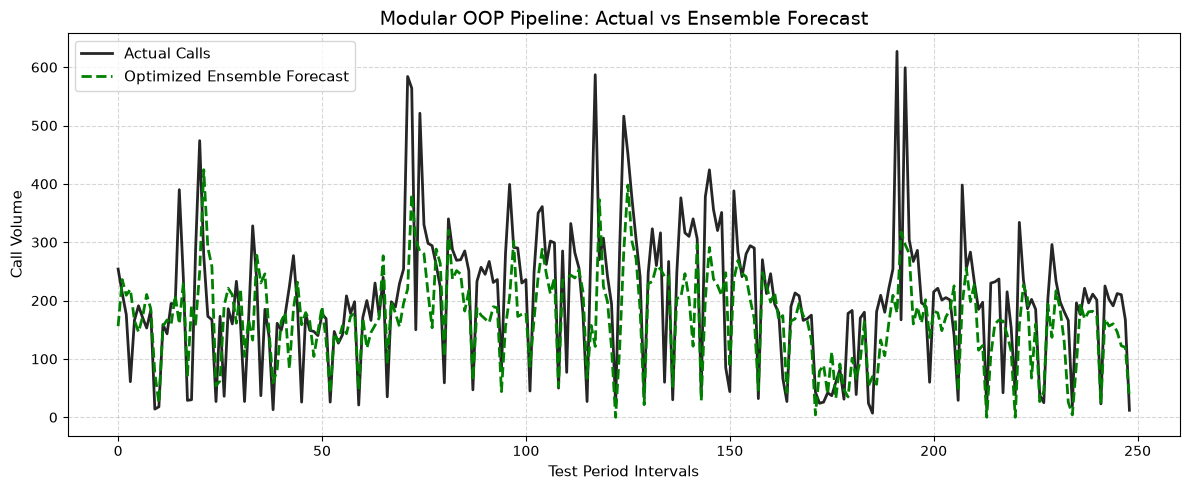

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Calls', color='black', linewidth=2, alpha=0.85)
plt.plot(ensemble_pred, label='Optimized Ensemble Forecast', color='green', linestyle='--', linewidth=2)

plt.title('Modular OOP Pipeline: Actual vs Ensemble Forecast', fontsize=14)
plt.xlabel('Test Period Intervals', fontsize=11)
plt.ylabel('Call Volume', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
